# Compare saved Galaxy Zoo experiments

Analyse completed **Slurm arrays, sequential benchmarks, or individual runs** without
training models, loading checkpoints, or requiring a GPU. Start with **Run all** after
editing the paths below. The input files are read-only; exports are optional.

This notebook shows learning curves, validation-selected epochs, aggregate and per-class
scores, runtime/memory, and paired changes between experiments. Use **validation** to
choose settings. Test scores describe the completed experiments and should not guide
repeated tuning. A single seed does not establish a reliable advantage for one model.

On the HPC, use its `.venv` kernel. Locally, copy the selected `runs/...` directories and
matching `results/...` directories into the same layout under a local artifact root.
Raw images and checkpoints are unnecessary. Saved absolute HPC paths are relocated
against `RESULTS_ROOT` below, so copied artifacts work on Windows too.

In [1]:
from pathlib import Path, PurePosixPath
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display

ROOT = Path().cwd().parent
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
pd.set_option('display.max_columns', 25)

In [3]:
# EDIT THIS CELL. On a laptop, change ARTIFACT_ROOT to your downloaded artifact folder.
ARTIFACT_ROOT = ROOT
RESULTS_ROOT = ROOT / 'results'
EXPERIMENTS = {
    'scheduled': ARTIFACT_ROOT / 'runs' / 'full128_array_12560',
    'shorter_training': ARTIFACT_ROOT / 'runs' / 'full128_array_12546',
    'longer_training': ARTIFACT_ROOT / 'runs' / 'full128_array_12554',
    # 'lr_decay': ARTIFACT_ROOT / 'runs' / 'full128_array_DECAY_JOB_ID',
}
REFERENCE_EXPERIMENT = 'scheduled'
SHOW_TEST_RESULTS = True  # Descriptive reporting only; tune using validation.
SHOW_CONFUSION_MATRICES = True
EXPORT_RESULTS = False
EXPORT_DIR = ROOT / 'results' / 'analysis'
# Optional HPC exports; leave empty to use only the original analysis.
SPLIT_EVALUATIONS = {
    # 'scheduled': RESULTS_ROOT / 'split_evaluation' / 'full128_array_12560',
}


## Load and validate artifacts

Completed runs need `history.json`, `runtime.json`, and `resolved_config.json`.
Incomplete runs are listed and skipped. Missing evaluation files still allow validation
analysis. Mixing dataset identities, or counting the same model/seed twice within an
experiment, raises an error. The settings table helps detect other differences; different
model architectures are intentional, but unrelated training changes can confound comparisons.

In [4]:
def read_json(path):
    return json.loads(path.read_text(encoding='utf-8'))


def evaluation_path(run_dir, config):
    # A resumed run may point to a nested results/.../resumed_TIMESTAMP directory.
    comparison_path = run_dir / 'comparison.json'
    entries = read_json(comparison_path) if comparison_path.exists() else []
    saved = next((entry.get('evaluation_dir') for entry in entries
                  if PurePosixPath(str(entry.get('run_dir', '')).replace('\\', '/')).name
                  == run_dir.name), None)
    if saved:
        parts = PurePosixPath(saved.replace('\\', '/')).parts
        if run_dir.name in parts:
            relocated = RESULTS_ROOT.joinpath(*parts[parts.index(run_dir.name):])
            if (relocated / 'metrics.json').exists():
                return relocated
        original = Path(saved)
        if (original / 'metrics.json').exists():
            return original
        # Do not silently substitute older metrics for missing resumed metrics.
        return None
    candidates = [RESULTS_ROOT / run_dir.name,
                  Path(config['paths']['results_dir']) / run_dir.name]
    return next((p for p in candidates if (p / 'metrics.json').exists()), None)


records, histories, evaluations, configs, skipped = [], {}, {}, {}, []
seen_paths = set()
for experiment, run_root in EXPERIMENTS.items():
    run_root = Path(run_root).expanduser()
    if not run_root.is_dir():
        warnings.warn(f'{experiment}: directory not found: {run_root}')
        continue
    for history_path in sorted(run_root.rglob('history.json')):
        run_dir = history_path.parent
        if run_dir.resolve() in seen_paths:
            raise ValueError(f'Overlapping experiment roots include the same run: {run_dir}')
        seen_paths.add(run_dir.resolve())
        required = [run_dir / name for name in ('runtime.json', 'resolved_config.json')]
        if not all(p.exists() for p in required):
            skipped.append({'experiment': experiment, 'run_dir': str(run_dir),
                            'reason': 'Incomplete: runtime/config missing'})
            continue
        runtime, config = map(read_json, required)
        history = pd.DataFrame(read_json(history_path)).sort_values('epoch').reset_index(drop=True)
        if history.empty:
            skipped.append({'experiment': experiment, 'run_dir': str(run_dir), 'reason': 'Empty history'})
            continue
        needed = ['epoch', 'train_loss', 'validation_loss', 'macro_f1', 'epoch_seconds']
        if not set(needed).issubset(history.columns) or not np.isfinite(history[needed].to_numpy()).all():
            raise ValueError(f'Missing/non-finite history fields: {run_dir}')
        if not np.array_equal(history['epoch'].to_numpy(), np.arange(len(history))):
            raise ValueError(f'Non-contiguous or duplicated epoch history: {run_dir}')
        model, seed = runtime['model'], int(runtime['seed'])
        key = (experiment, model, seed)
        if key in histories:
            raise ValueError(f'Duplicate experiment/model/seed: {key}. Select narrower run roots.')
        history['epoch_display'] = history['epoch'] + 1
        best = history.loc[history['macro_f1'].idxmax()]
        stopped = int(history['epoch_display'].iloc[-1])
        best_epoch = int(best['epoch_display'])
        patience = int(config['training']['early_stopping_patience'])
        maximum = int(config['training']['epochs'])
        stale_epochs = stopped - best_epoch
        at_limit, at_patience = stopped >= maximum, patience > 0 and stale_epochs >= patience
        reason = ('epoch limit + patience' if at_limit and at_patience else
                  'early stopping' if at_patience else 'epoch limit' if at_limit else 'other / inspect log')
        row = dict(experiment=experiment, model=model, seed=seed, dataset_id=runtime['dataset_id'],
                   image_size=config['data']['image_size'], epochs_completed=stopped,
                   best_epoch=best_epoch, max_epochs=maximum, patience=patience, stop_reason=reason,
                   best_val_macro_f1=best['macro_f1'], last_val_macro_f1=history['macro_f1'].iloc[-1],
                   best_val_loss=history['validation_loss'].min(),
                   last_val_loss=history['validation_loss'].iloc[-1],
                   epoch_hours=history['epoch_seconds'].sum() / 3600,
                   invocation_hours=runtime['elapsed_seconds'] / 3600,
                   peak_rss_gib=runtime['peak_process_rss_bytes'] / 2**30,
                   peak_gpu_reserved_gib=runtime['peak_gpu_reserved_bytes'] / 2**30,
                   parameters=runtime.get('parameter_count', np.nan),
                   batch_size=config['training']['batch_size'],
                   learning_rate=config['training']['learning_rate'],
                   scheduler=config.get('scheduler', {}).get('name', 'none'),
                   scheduler_monitor=config.get('scheduler', {}).get('monitor', 'macro_f1'),
                   run_dir=str(run_dir), test_accuracy=np.nan, test_macro_f1=np.nan,
                   test_balanced_accuracy=np.nan)
        result_dir = evaluation_path(run_dir, config) if SHOW_TEST_RESULTS else None
        if result_dir is not None:
            metrics = read_json(result_dir / 'metrics.json')
            if metrics.get('dataset_id') != row['dataset_id'] or metrics.get('model_mode') != model:
                raise ValueError(f'Evaluation does not match training: {result_dir}')
            row.update({f'test_{name}': metrics[name]
                        for name in ('accuracy', 'macro_f1', 'balanced_accuracy')})
            evaluations[key] = (metrics, result_dir)
        elif SHOW_TEST_RESULTS:
            warnings.warn(f'Test report missing for {key}; validation plots remain available.')
        histories[key], configs[key] = history, config
        records.append(row)

if skipped:
    display(pd.DataFrame(skipped))
if not records:
    raise FileNotFoundError('No completed runs found. Edit EXPERIMENTS and ARTIFACT_ROOT above.')
runs = pd.DataFrame(records).sort_values(['experiment', 'model', 'seed']).reset_index(drop=True)
if runs['dataset_id'].nunique() != 1:
    raise ValueError('Selected runs use different datasets/splits. Analyse them separately.')
print(f'Loaded {len(runs)} runs; dataset {runs.dataset_id.iloc[0]}')

Loaded 9 runs; dataset 9793e662d43a2596fb56bf131c7ee99882ed5adca9ab146e90a7cf8121d24268


## Scores, stopping epochs, and settings

Epoch numbers below are **1-based**. Best epochs maximize validation macro-F1, matching
checkpoint selection. Test scores belong to those checkpoints, not necessarily the last
epoch. `epoch_hours` sums the saved epoch timings across the whole history; it excludes
checkpoint writes and setup. `invocation_hours` is the most recent training invocation,
including validation/checkpointing; after resume it does not cover the whole history.

RSS includes loader workers and can count shared pages more than once. GPU reservation
is the PyTorch allocator peak, not total device memory. These resource peaks describe
training/validation; standalone test evaluation has its own runtime report.

In [5]:
score_columns = ['experiment', 'model', 'seed', 'best_val_macro_f1']
if SHOW_TEST_RESULTS:
    score_columns += ['test_accuracy', 'test_macro_f1', 'test_balanced_accuracy']
score_columns += ['best_epoch', 'epochs_completed', 'stop_reason', 'epoch_hours', 'parameters']
display(runs[score_columns].round(4))
display(runs[['experiment', 'model', 'seed', 'max_epochs', 'patience', 'batch_size',
              'learning_rate', 'scheduler', 'scheduler_monitor',
              'peak_rss_gib', 'peak_gpu_reserved_gib', 'invocation_hours']].round(4))

# Inspect all saved architecture/training choices for a selected run if needed:
# display(configs[('baseline', 'qufex', 42)])

,experiment,model,seed,best_val_macro_f1,test_accuracy,test_macro_f1,test_balanced_accuracy,best_epoch,epochs_completed,stop_reason,epoch_hours,parameters
0,longer_training,cnn_replacement,42,0.8062,0.8165,0.8062,0.7974,52,67,early stopping,3.2251,14873
1,longer_training,direct_cnn,42,0.8091,0.8188,0.8084,0.7983,40,55,early stopping,1.2606,25875
2,longer_training,qufex,42,0.8072,0.8152,0.8050,0.7908,40,55,early stopping,13.1045,14707
3,scheduled,cnn_replacement,42,0.8021,0.8140,0.8050,0.8000,38,53,early stopping,2.6446,14873
4,scheduled,direct_cnn,42,0.8164,0.8264,0.8172,0.8135,83,98,early stopping,2.2685,25875
5,scheduled,qufex,42,0.8082,0.8191,0.8085,0.7967,40,55,early stopping,13.0851,14707
6,shorter_training,cnn_replacement,42,0.7992,0.8127,0.7965,0.7858,34,42,early stopping,2.0786,14873
7,shorter_training,direct_cnn,42,0.7988,0.8125,0.7992,0.7846,24,32,early stopping,0.7249,25875
8,shorter_training,qufex,42,0.8000,0.8117,0.7986,0.7793,40,48,early stopping,11.3035,14707


,experiment,model,seed,max_epochs,patience,batch_size,learning_rate,scheduler,scheduler_monitor,peak_rss_gib,peak_gpu_reserved_gib,invocation_hours
0,longer_training,cnn_replacement,42,100,15,8,0.001,none,macro_f1,8.5798,0.6016,3.2258
1,longer_training,direct_cnn,42,100,15,8,0.001,none,macro_f1,8.2839,0.6289,1.2610
2,longer_training,qufex,42,100,15,8,0.001,none,macro_f1,8.8220,0.6035,13.1051
3,scheduled,cnn_replacement,42,100,15,8,0.001,reduce_on_plateau,macro_f1,8.5240,0.6016,2.6451
4,scheduled,direct_cnn,42,100,15,8,0.001,reduce_on_plateau,macro_f1,8.3046,0.6289,2.2693
5,scheduled,qufex,42,100,15,8,0.001,reduce_on_plateau,macro_f1,8.7924,0.6035,13.0857
6,shorter_training,cnn_replacement,42,50,8,8,0.001,none,macro_f1,8.5126,0.6016,2.0791
7,shorter_training,direct_cnn,42,50,8,8,0.001,none,macro_f1,8.2860,0.6289,0.7251
8,shorter_training,qufex,42,50,8,8,0.001,none,macro_f1,8.7980,0.6035,11.3040


## Learning curves

Each column is one model. Colours identify experiments; when multiple seeds are selected,
each gets a separate line. Dashed vertical lines mark each run's best validation-F1 epoch.
Training uses augmentation and dropout, while validation does not, so the losses are not
directly equivalent measurements of generalization error. F1 is unsmoothed to expose noise.

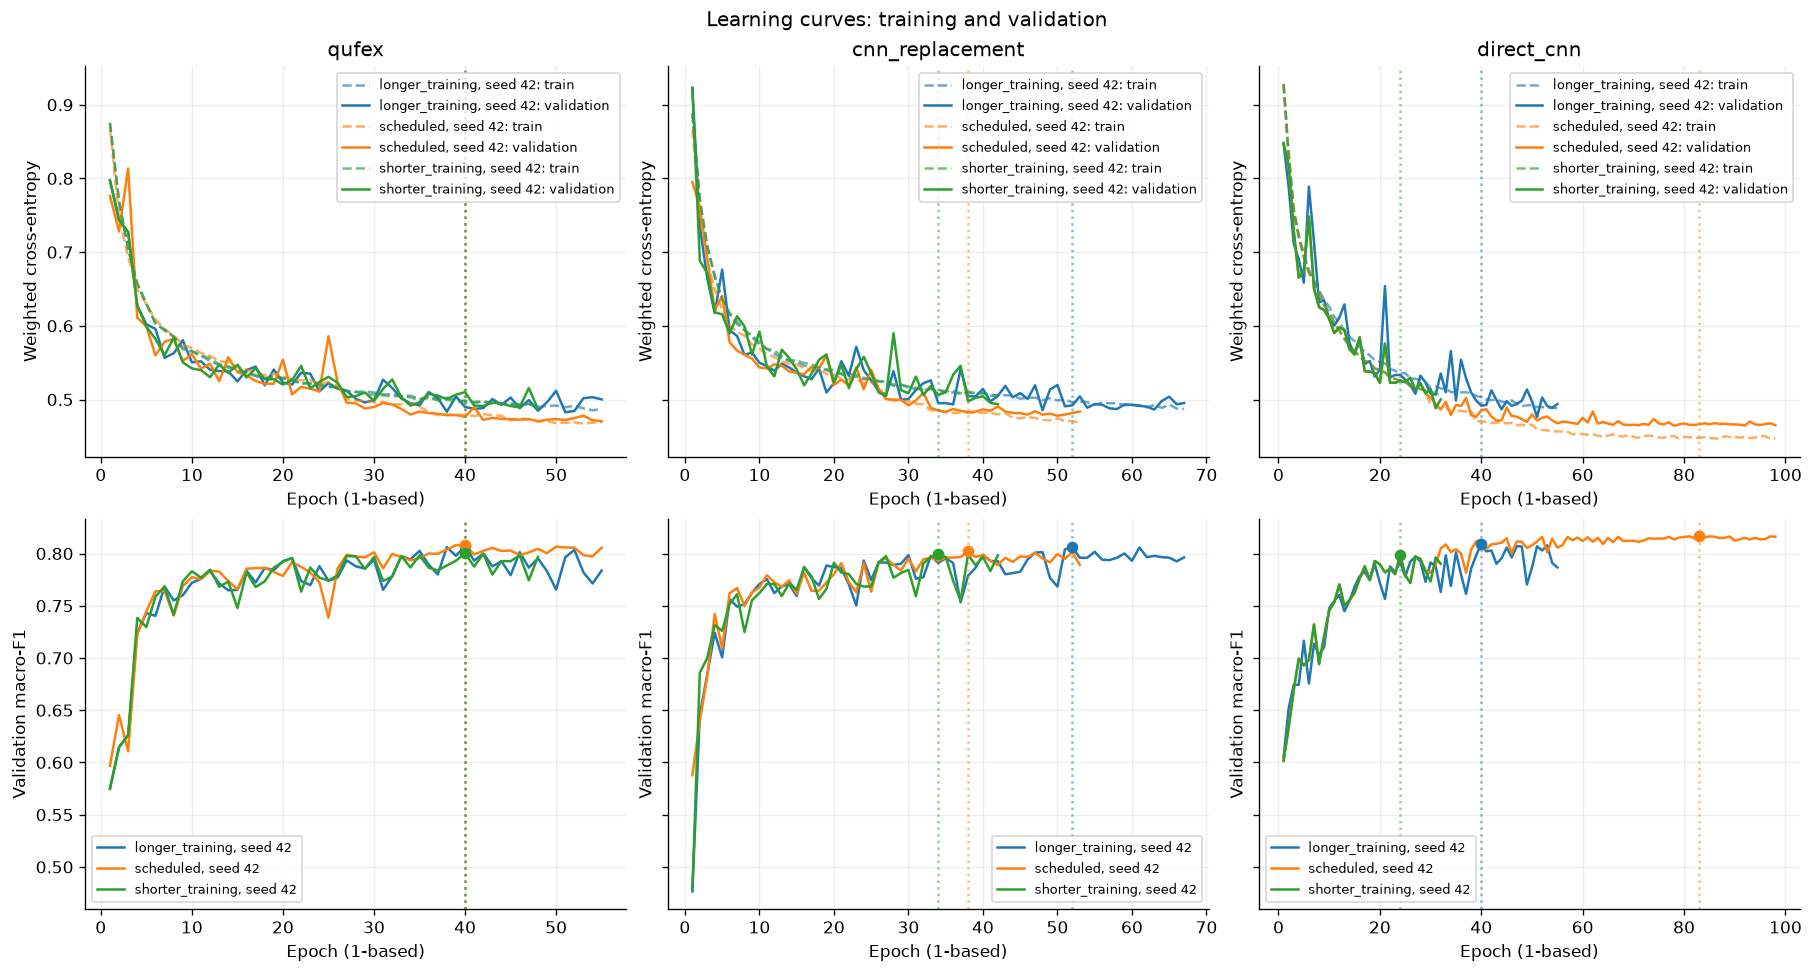

In [6]:
preferred = ['qufex', 'cnn_replacement', 'direct_cnn']
model_order = [m for m in preferred if m in runs.model.unique()]
model_order += sorted(set(runs.model) - set(model_order))
experiment_order = list(dict.fromkeys(runs.experiment))
colours = {e: plt.get_cmap('tab10')(i % 10) for i, e in enumerate(experiment_order)}
figures = {}
fig, axes = plt.subplots(2, len(model_order), figsize=(5 * len(model_order), 8),
                         sharey='row', squeeze=False, constrained_layout=True)
for column, model in enumerate(model_order):
    for row in runs[runs.model == model].itertuples():
        h = histories[(row.experiment, model, row.seed)]
        colour = colours[row.experiment]
        label = f'{row.experiment}, seed {row.seed}'
        axes[0, column].plot(h.epoch_display, h.train_loss, '--', color=colour,
                            alpha=0.65, label=f'{label}: train')
        axes[0, column].plot(h.epoch_display, h.validation_loss, color=colour,
                            label=f'{label}: validation')
        axes[1, column].plot(h.epoch_display, h.macro_f1, color=colour, label=label)
        axes[1, column].scatter(row.best_epoch, row.best_val_macro_f1, color=colour, zorder=3)
        for ax in axes[:, column]:
            ax.axvline(row.best_epoch, color=colour, linestyle=':', alpha=0.5)
    axes[0, column].set_title(model)
    axes[0, column].set_ylabel('Weighted cross-entropy')
    axes[1, column].set_ylabel('Validation macro-F1')
    for ax in axes[:, column]:
        ax.set_xlabel('Epoch (1-based)')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8)
fig.suptitle('Learning curves: training and validation')
figures['learning_curves'] = fig
plt.show()

## Learning-rate schedule

These curves show the rate **used during each epoch**. A reduction recorded in
`next_learning_rate` takes effect only if another epoch is trained. For older
fixed-rate runs without LR history, the configured constant rate is shown. Missing
rates for a scheduled run are not inferred from its starting rate. The display
uses a log scale; zero rates are omitted with a warning.

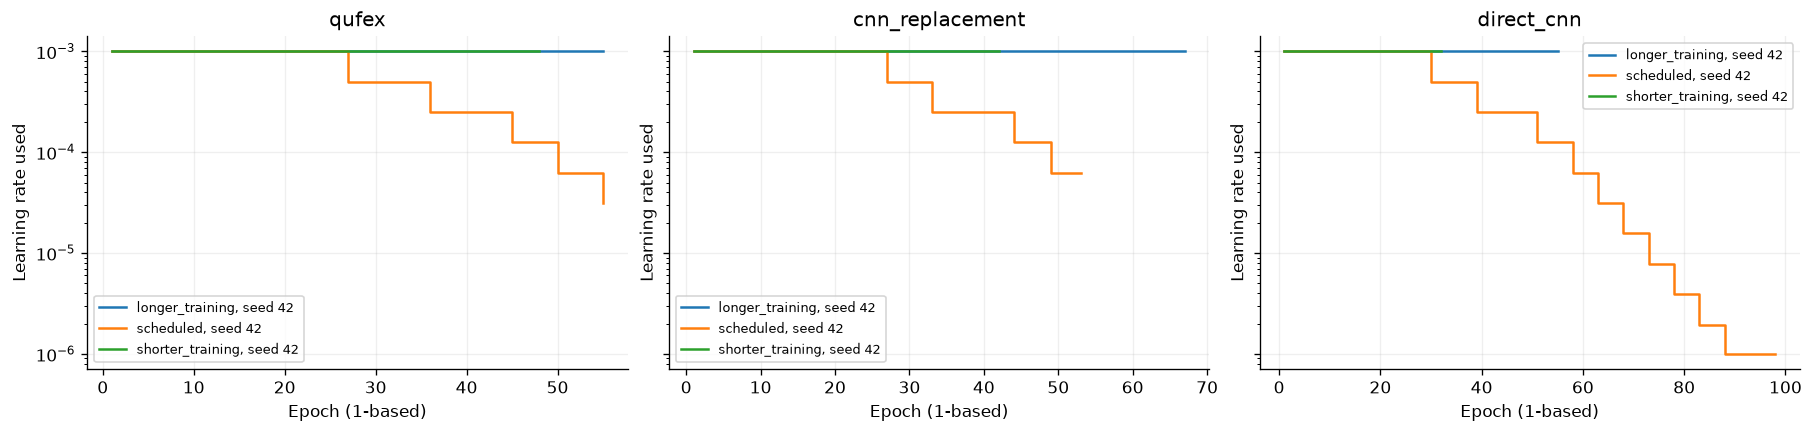

In [7]:
fig, axes = plt.subplots(1, len(model_order), figsize=(5 * len(model_order), 3.5),
                         squeeze=False, sharey=True, constrained_layout=True)
for ax, model in zip(axes[0], model_order):
    for row in runs[runs.model == model].itertuples():
        key = (row.experiment, model, row.seed)
        h = histories[key]
        if 'learning_rate' in h:
            rates = h.learning_rate.copy()
            if row.scheduler == 'none':
                rates = rates.fillna(row.learning_rate)
        elif row.scheduler == 'none':
            rates = pd.Series(row.learning_rate, index=h.index)
        else:
            warnings.warn(f'No learning-rate history for scheduled run {key}')
            continue
        if rates.isna().any():
            warnings.warn(f'Incomplete learning-rate history for {key}')
        if (rates <= 0).any():
            warnings.warn(f'Non-positive learning rates omitted from log plot for {key}')
        ax.step(h.epoch_display, rates.where(rates > 0), where='post',
                color=colours[row.experiment], label=f'{row.experiment}, seed {row.seed}')
    ax.set_title(model)
    ax.set_xlabel('Epoch (1-based)')
    ax.set_ylabel('Learning rate used')
    ax.set_yscale('log')
    ax.grid(alpha=0.2)
    if ax.lines:
        ax.legend(fontsize=8)
figures['learning_rates'] = fig
plt.show()

## Score comparisons across seeds

Bars are means across seeds **within each experiment and model**. Error bars are sample
standard deviations, not confidence intervals. Single-seed bars have no error bar; missing
standard deviations are not zero. Missing test reports are excluded from test aggregates.

,experiment,model,metric,n,mean,std
0,longer_training,cnn_replacement,best_val_macro_f1,1,0.8062,NaN
1,longer_training,direct_cnn,best_val_macro_f1,1,0.8091,NaN
2,longer_training,qufex,best_val_macro_f1,1,0.8072,NaN
3,scheduled,cnn_replacement,best_val_macro_f1,1,0.8021,NaN
4,scheduled,direct_cnn,best_val_macro_f1,1,0.8164,NaN
5,scheduled,qufex,best_val_macro_f1,1,0.8082,NaN
6,shorter_training,cnn_replacement,best_val_macro_f1,1,0.7992,NaN
7,shorter_training,direct_cnn,best_val_macro_f1,1,0.7988,NaN
8,shorter_training,qufex,best_val_macro_f1,1,0.8000,NaN
9,longer_training,cnn_replacement,test_macro_f1,1,0.8062,NaN


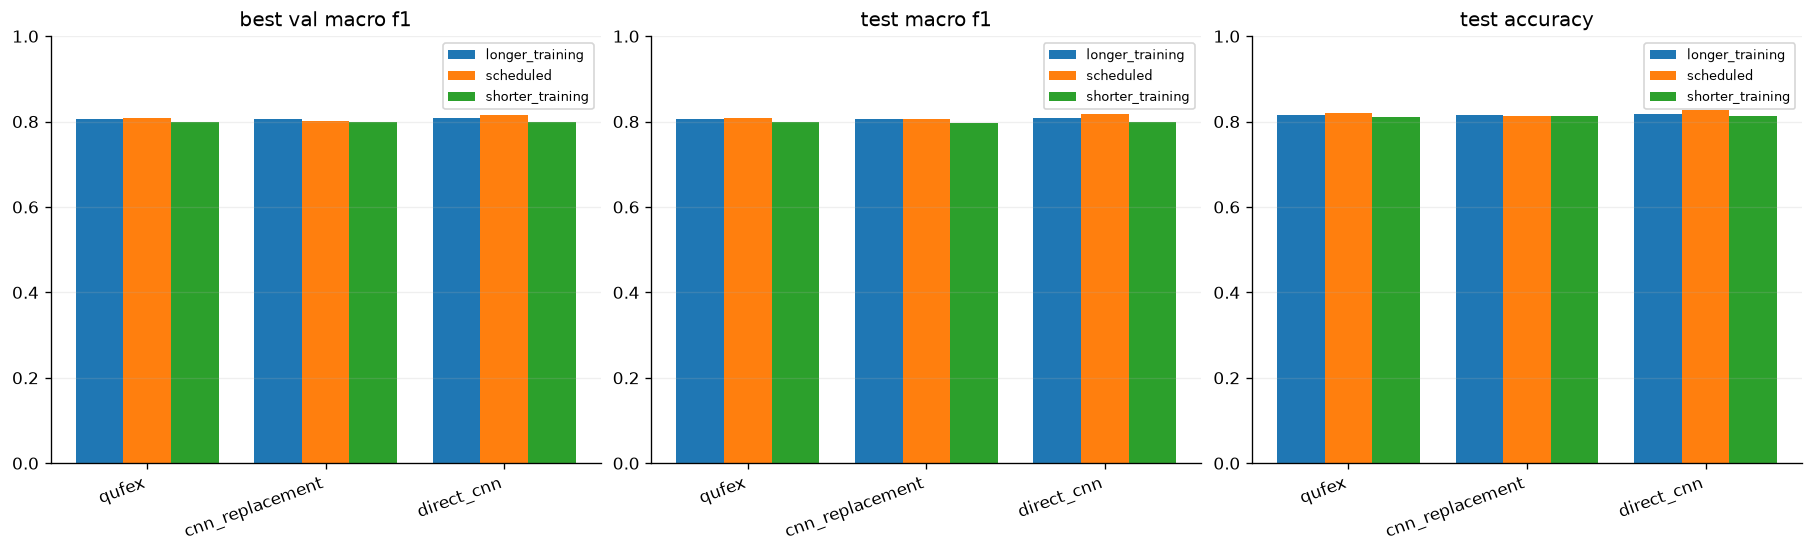

In [8]:
metrics_to_compare = ['best_val_macro_f1']
if SHOW_TEST_RESULTS:
    metrics_to_compare += ['test_macro_f1', 'test_accuracy']
long_scores = runs.melt(id_vars=['experiment', 'model', 'seed'], value_vars=metrics_to_compare,
                       var_name='metric', value_name='score').dropna(subset=['score'])
score_summary = (long_scores.groupby(['experiment', 'model', 'metric'], sort=False)['score']
                 .agg(n='count', mean='mean', std='std').reset_index())
display(score_summary.round(4))
fig, axes = plt.subplots(1, len(metrics_to_compare), figsize=(5 * len(metrics_to_compare), 4.5),
                         squeeze=False, constrained_layout=True)
positions = np.arange(len(model_order))
width = 0.8 / len(experiment_order)
for ax, metric in zip(axes[0], metrics_to_compare):
    for index, experiment in enumerate(experiment_order):
        frame = (score_summary[(score_summary.experiment == experiment) & (score_summary.metric == metric)]
                 .set_index('model').reindex(model_order))
        x = positions + (index - (len(experiment_order) - 1) / 2) * width
        ax.bar(x, frame['mean'], width, label=experiment, color=colours[experiment])
        available = frame['std'].notna().to_numpy()
        if available.any():
            ax.errorbar(x[available], frame['mean'].to_numpy()[available],
                        yerr=frame['std'].to_numpy()[available], fmt='none', color='black', capsize=3)
    ax.set_xticks(positions, model_order, rotation=20, ha='right')
    ax.set_ylim(0, 1)
    ax.set_title(metric.replace('_', ' '))
    ax.grid(axis='y', alpha=0.2)
    ax.legend(fontsize=8)
figures['score_comparison'] = fig
plt.show()

## Paired changes versus the reference experiment

Compare the **same model and seed** on the same dataset. Positive score deltas mean the
candidate did better. Unmatched seeds are listed; they are not silently averaged together.
Inspect settings above to confirm the intended controlled change (e.g. epochs/patience).

In [9]:
paired_tables = []
reference = runs[runs.experiment == REFERENCE_EXPERIMENT]
if reference.empty:
    warnings.warn(f'Reference experiment not loaded: {REFERENCE_EXPERIMENT}')
for experiment in experiment_order:
    if experiment == REFERENCE_EXPERIMENT or reference.empty:
        continue
    candidate = runs[runs.experiment == experiment]
    matched = candidate.merge(reference, on=['model', 'seed', 'dataset_id'],
                              suffixes=('_candidate', '_reference'), how='outer',
                              indicator=True, validate='one_to_one')
    unmatched = matched[matched['_merge'] != 'both']
    if not unmatched.empty:
        print(f'{experiment}: unmatched runs')
        display(unmatched[['model', 'seed', '_merge']])
    matched = matched[matched['_merge'] == 'both'].copy()
    paired = matched[['model', 'seed']].copy()
    paired.insert(0, 'experiment', experiment)
    paired.insert(1, 'reference', REFERENCE_EXPERIMENT)
    for metric in metrics_to_compare:
        paired[f'delta_{metric}'] = matched[f'{metric}_candidate'] - matched[f'{metric}_reference']
    paired['delta_epochs'] = matched.epochs_completed_candidate - matched.epochs_completed_reference
    paired_tables.append(paired)
paired_deltas = pd.concat(paired_tables, ignore_index=True) if paired_tables else pd.DataFrame()
if not paired_deltas.empty:
    display(paired_deltas.round(4))
else:
    print('Add another experiment root to compare settings on matched seeds.')

,experiment,reference,model,seed,delta_best_val_macro_f1,delta_test_macro_f1,delta_test_accuracy,delta_epochs
0,longer_training,scheduled,cnn_replacement,42,0.0040,0.0012,0.0026,14
1,longer_training,scheduled,direct_cnn,42,-0.0074,-0.0088,-0.0076,-43
2,longer_training,scheduled,qufex,42,-0.0010,-0.0036,-0.0039,0
3,shorter_training,scheduled,cnn_replacement,42,-0.0029,-0.0085,-0.0013,-11
4,shorter_training,scheduled,direct_cnn,42,-0.0176,-0.0180,-0.0139,-66
5,shorter_training,scheduled,qufex,42,-0.0082,-0.0099,-0.0074,-7


## Test error breakdown (descriptive)

Per-class precision/recall/F1 and saved confusion matrices describe the selected checkpoints.
Use analogous **validation** error analysis for decisions about class weighting, architecture,
or augmentation. Turn off `SHOW_TEST_RESULTS` when working only on model selection.

,experiment,model,seed,class_name,precision,recall,f1,support
0,scheduled,cnn_replacement,42,smooth,0.8450,0.8851,0.8646,6504
1,scheduled,cnn_replacement,42,unbarred_spiral,0.7482,0.7119,0.7296,4287
2,scheduled,cnn_replacement,42,barred_spiral,0.8392,0.8030,0.8207,2340
3,scheduled,direct_cnn,42,smooth,0.8457,0.9036,0.8737,6504
4,scheduled,direct_cnn,42,unbarred_spiral,0.7847,0.7082,0.7445,4287
5,scheduled,direct_cnn,42,barred_spiral,0.8383,0.8286,0.8334,2340
6,scheduled,qufex,42,smooth,0.8240,0.9210,0.8698,6504
7,scheduled,qufex,42,unbarred_spiral,0.7783,0.6821,0.7270,4287
8,scheduled,qufex,42,barred_spiral,0.8751,0.7872,0.8288,2340
9,shorter_training,cnn_replacement,42,smooth,0.8107,0.9382,0.8698,6504


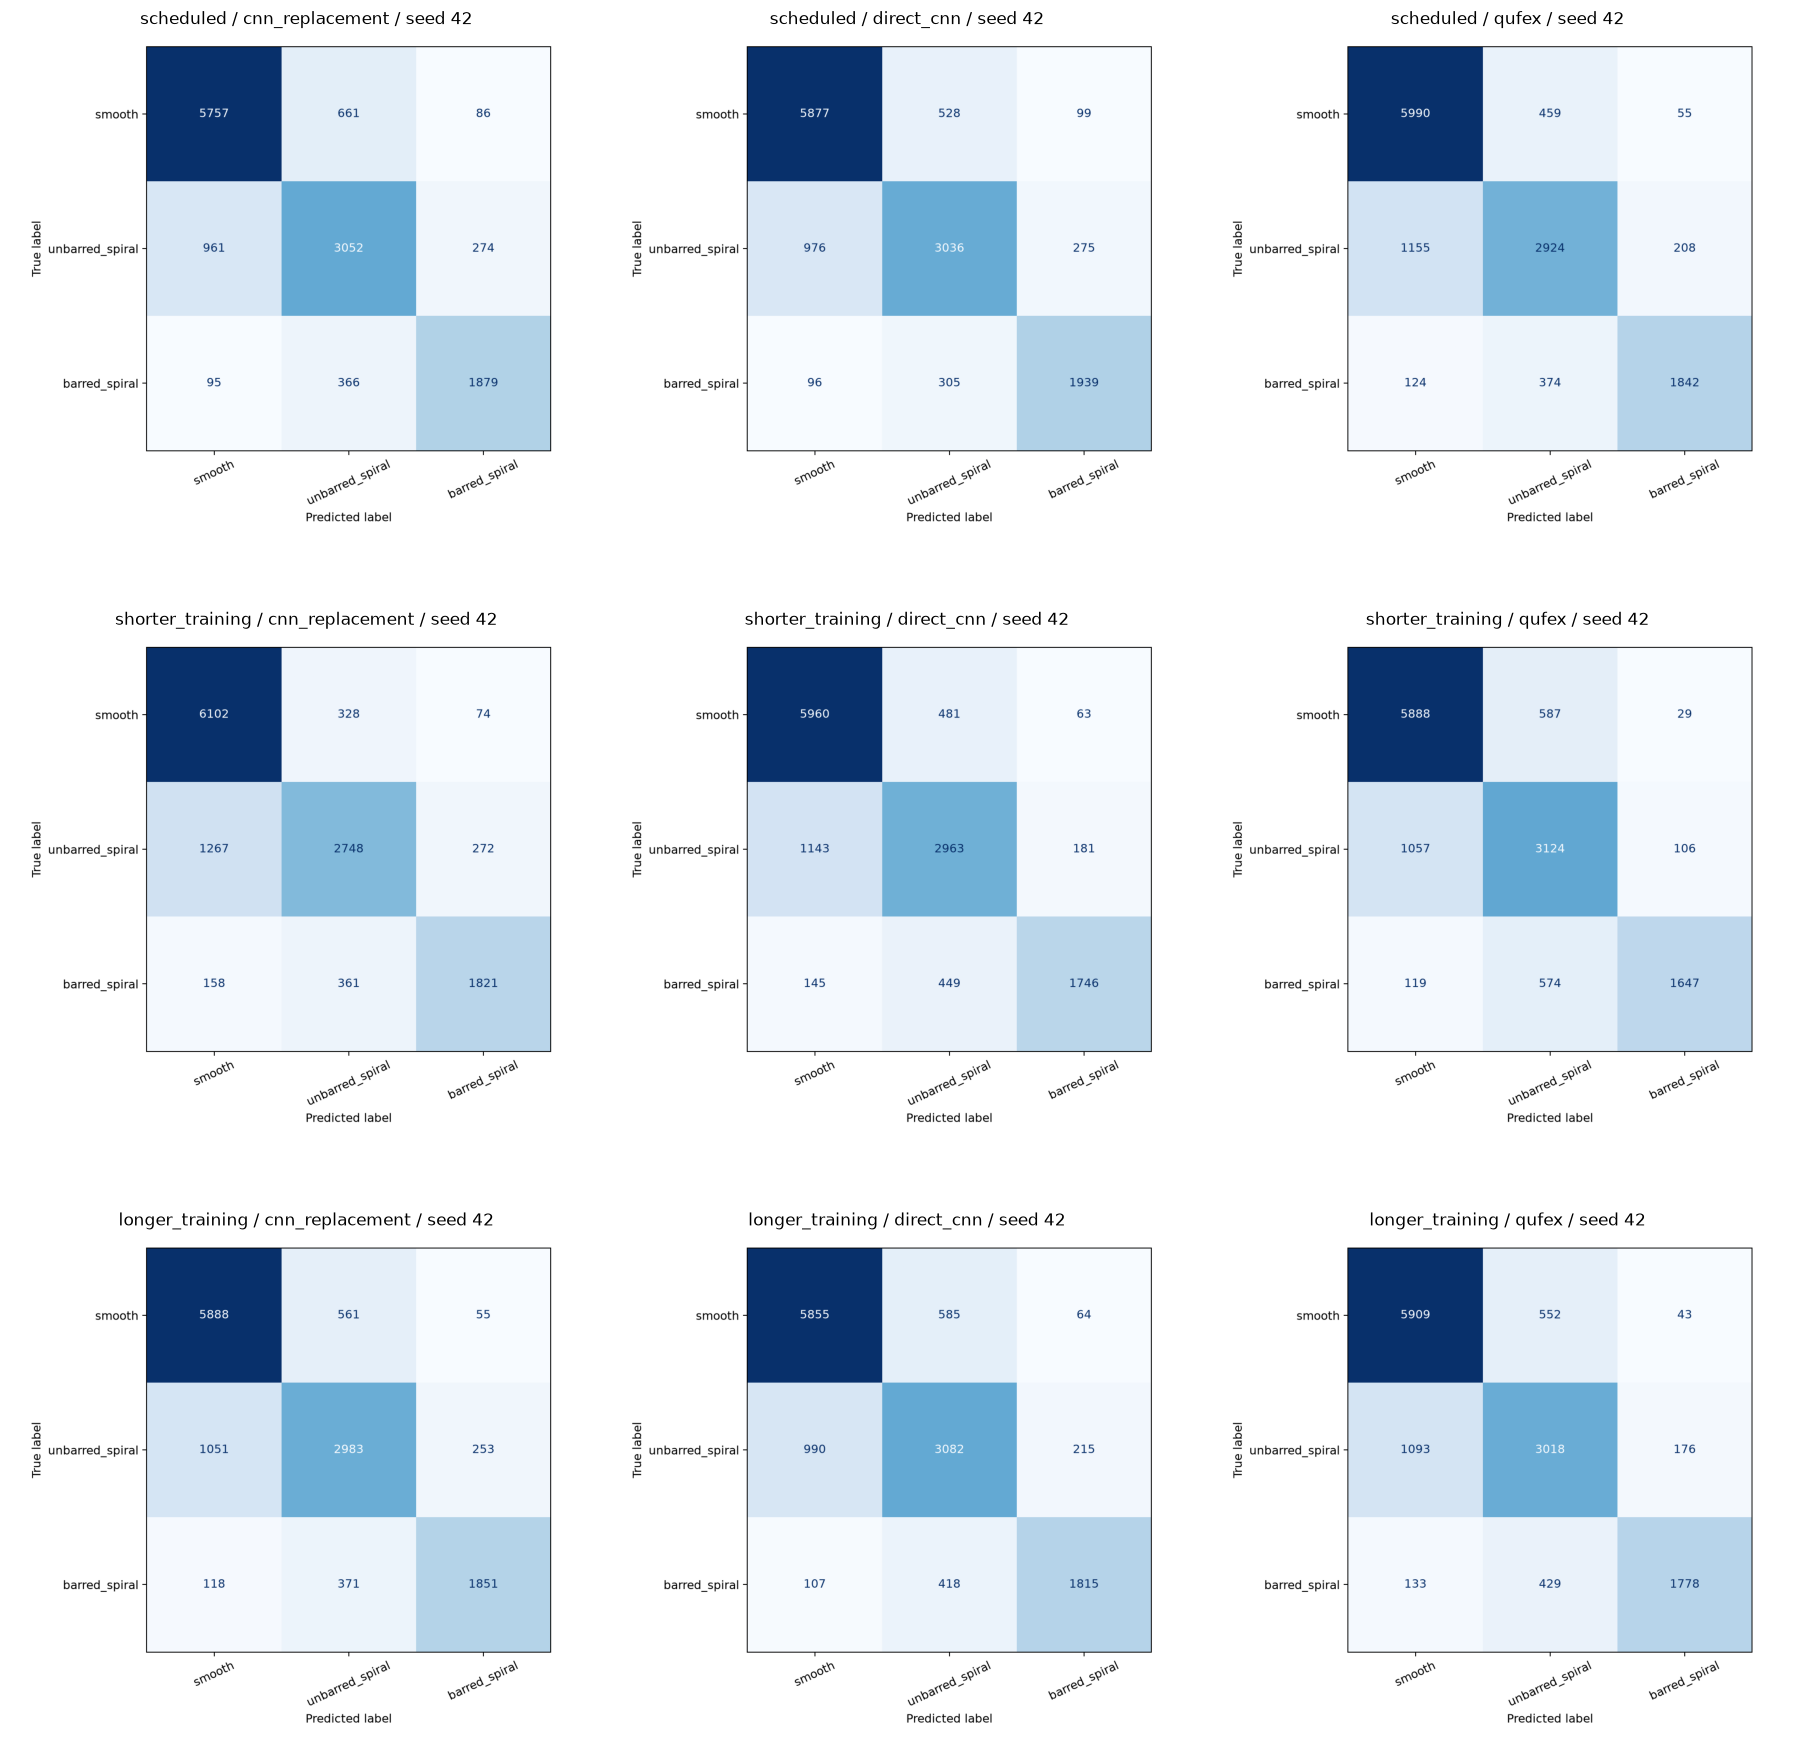

In [10]:
class_rows = []
for (experiment, model, seed), (metrics, result_dir) in evaluations.items():
    for class_name, values in metrics.get('per_class', {}).items():
        class_rows.append(dict(experiment=experiment, model=model, seed=seed,
                               class_name=class_name, **values))
per_class = pd.DataFrame(class_rows)
if not per_class.empty:
    display(per_class.round(4))
if SHOW_TEST_RESULTS and SHOW_CONFUSION_MATRICES:
    available = [(key, directory / 'confusion_matrix.png')
                 for key, (_, directory) in evaluations.items()
                 if (directory / 'confusion_matrix.png').exists()]
    if available:
        columns = min(3, len(available))
        rows_count = (len(available) + columns - 1) // columns
        fig, axes = plt.subplots(rows_count, columns, figsize=(5 * columns, 5 * rows_count),
                                 squeeze=False, constrained_layout=True)
        for ax, (key, image_path) in zip(axes.flat, available):
            ax.imshow(mpimg.imread(image_path))
            ax.set_title(f'{key[0]} / {key[1]} / seed {key[2]}', fontsize=10)
            ax.axis('off')
        for ax in list(axes.flat)[len(available):]:
            ax.axis('off')
        figures['test_confusion_matrices'] = fig
        plt.show()

## How to decide what to try next

- **Epoch limit reached, validation still improving:** test a higher maximum epoch count.
- **Patience reached, validation F1 noisy but validation loss still decreasing:** compare
  a longer patience under the same training settings. Extra epochs are an experiment,
  not a guaranteed improvement. Increasing only the epoch limit does not change patience.
- **Training loss improves while validation loss consistently worsens:** investigate
  overfitting with validation data, including regularization/augmentation and model size.
- **Both curves flatten at unsatisfactory scores:** test optimization changes or capacity
  one at a time; curves alone do not establish the cause. Record training-set evaluation
  in eval mode if you need a comparable train/validation generalization gap.
- **Models differ only slightly:** repeat matched seeds and report variability before
  claiming an advantage. Runtime is also part of the comparison; distinguish total
  training time from per-epoch time when models stop at different epochs.

Use the saved resolved configuration as the record of what actually ran. The current
trainer supports optional ReduceLROnPlateau scheduling, but rejects changing the
scheduler, initial learning rate, or early-stopping patience during resume. Use fresh
experiments for those changes; resume restores the saved optimizer/scheduler state.
For a fair QuFeX/CNN-replacement ablation, apply shared encoder changes to both models.

## Best-checkpoint scores on train, validation, and test

Point `SPLIT_EVALUATIONS` at the small exports from `scripts.evaluate_experiment`.
Training scores evaluate the selected best checkpoint with augmentation and dropout
disabled; they are not online training-epoch scores. Precision and recall use macro
averaging (equal weight per class). All scores are fractions between 0 and 1.
Checkpoint epochs in the CSV are zero-based. Tables below also show a one-based epoch.
Missing exports do not prevent the original saved-run analysis above.


In [ ]:
split_frames, class_frames = [], []
for experiment, directory in SPLIT_EVALUATIONS.items():
    directory = Path(directory)
    paths = [directory / 'split_metrics.csv', directory / 'per_class_metrics.csv']
    if not all(path.is_file() for path in paths):
        warnings.warn(f'{experiment}: split evaluation exports missing in {directory}')
        continue
    frame, classes = (pd.read_csv(path) for path in paths)
    frame['experiment'] = classes['experiment'] = experiment
    if not SHOW_TEST_RESULTS:
        frame = frame[frame.split != 'test'].copy()
        classes = classes[classes.split != 'test'].copy()
    keys = ['experiment', 'model', 'seed', 'split']
    if frame.duplicated(keys).any() or classes.duplicated(keys + ['class_name']).any():
        raise ValueError(f'Duplicate split evaluation rows: {directory}')
    selected = runs[runs.experiment == experiment]
    if selected.empty:
        raise ValueError(f'Split evaluation has no selected experiment: {experiment}')
    for row in frame.itertuples():
        match = selected[(selected.model == row.model) & (selected.seed == row.seed)]
        if len(match) != 1 or match.iloc[0].dataset_id != row.dataset_id:
            raise ValueError(f'Split evaluation does not match selected runs: {experiment}/{row.model}/{row.seed}')
        if row.checkpoint_epoch + 1 != match.iloc[0].best_epoch:
            raise ValueError(f'Split evaluation checkpoint epoch differs from selected best epoch: {row.run}')
    provenance = keys + ['dataset_id', 'checkpoint', 'checkpoint_epoch']
    linked = classes.merge(frame[provenance], on=provenance, how='left', indicator=True, validate='many_to_one')
    if (linked['_merge'] != 'both').any():
        raise ValueError(f'Per-class provenance differs from split scores: {directory}')
    split_frames.append(frame)
    class_frames.append(classes)

split_scores = pd.concat(split_frames, ignore_index=True) if split_frames else pd.DataFrame()
split_per_class = pd.concat(class_frames, ignore_index=True) if class_frames else pd.DataFrame()
split_summary = pd.DataFrame()
expected_splits = ['train', 'validation', 'test'] if SHOW_TEST_RESULTS else ['train', 'validation']
missing_splits = []
for row in runs.itertuples():
    available = set() if split_scores.empty else set(split_scores.loc[
        (split_scores.experiment == row.experiment) & (split_scores.model == row.model) &
        (split_scores.seed == row.seed), 'split'])
    missing_splits.extend(dict(experiment=row.experiment, model=row.model, seed=row.seed, split=split)
                          for split in expected_splits if split not in available)
if missing_splits:
    print('Missing best-checkpoint split evaluations (run the HPC script to generate them):')
    display(pd.DataFrame(missing_splits))
if not split_scores.empty:
    split_scores['best_epoch'] = split_scores.checkpoint_epoch + 1
    columns = ['experiment', 'model', 'seed', 'split', 'best_epoch',
               'accuracy', 'macro_precision', 'macro_recall']
    display(split_scores[columns].round(4))
    display(split_per_class[['experiment', 'model', 'seed', 'split', 'class_name',
                             'precision', 'recall', 'f1', 'support']].round(4))
    long = split_scores.melt(id_vars=['experiment', 'model', 'seed', 'split'],
                             value_vars=['accuracy', 'macro_precision', 'macro_recall'],
                             var_name='metric', value_name='score')
    split_summary = (long.groupby(['experiment', 'model', 'split', 'metric'], sort=False)['score']
                     .agg(n='count', mean='mean', std='std').reset_index())
    display(split_summary.round(4))  # Single-seed standard deviations remain NaN.


In [24]:
# Optional exports go to a separate directory; original run artifacts are never overwritten.
if EXPORT_RESULTS:
    selected_roots = [Path(p).expanduser().resolve() for p in EXPERIMENTS.values()]
    destination = EXPORT_DIR.expanduser().resolve()
    if any(destination == p or p in destination.parents for p in selected_roots):
        raise ValueError('Choose an EXPORT_DIR outside the selected run roots.')
    destination.mkdir(parents=True, exist_ok=True)
    if not split_scores.empty:
        split_scores.to_csv(destination / 'split_metrics.csv', index=False)
        split_per_class.to_csv(destination / 'per_class_metrics.csv', index=False)
        split_summary.to_csv(destination / 'split_summary.csv', index=False)
    runs.to_csv(destination / 'run_comparison.csv', index=False)
    score_summary.to_csv(destination / 'score_summary.csv', index=False)
    if not paired_deltas.empty:
        paired_deltas.to_csv(destination / 'paired_deltas.csv', index=False)
    if not per_class.empty:
        per_class.to_csv(destination / 'test_per_class.csv', index=False)
    for name, fig in figures.items():
        fig.savefig(destination / f'{name}.png', dpi=160, bbox_inches='tight')
        fig.savefig(destination / f'{name}.pdf', bbox_inches='tight')
    print(f'Exported tables and figures to {destination}')
else:
    print('Exports disabled. Set EXPORT_RESULTS = True in the settings cell to save tables/plots.')

Exports disabled. Set EXPORT_RESULTS = True in the settings cell to save tables/plots.
